In [1]:
# Step 1: Imports
from ast import literal_eval
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from model.HMM import HMM
from model.label_maps import NER_TAG_TO_INDEX, INDEX_TO_NER_TAG

In [2]:
# Step 2: Load dataset
df = pd.read_parquet('./data/data.parquet')
df = pd.DataFrame(df)

print('Rows:', len(df))
print('Columns:', list(df.columns))
df.head(2)

Rows: 21588
Columns: ['masked_text', 'unmasked_text', 'token_entity_labels', 'tokenised_unmasked_text']


,masked_text,unmasked_text,token_entity_labels,tokenised_unmasked_text
0,[PREFIX_1] [FIRSTNAME_1] [MIDDLENAME_1] [LASTN...,"Mr. Adolphus Reagan Ziemann, as a Central Prin...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[mr, ., adolph, ##us, reagan, z, ##ie, ##mann,..."
1,"Hello [FIRSTNAME_1], would you please investig...","Hello Hannah, would you please investigate the...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[hello, hannah, ,, would, you, please, investi..."


In [3]:
# Step 3: Train/test split and model input frames
train_combined, test_combined = train_test_split(df, test_size=0.2, random_state=42)

train_df = pd.DataFrame({
    'tokens': train_combined['tokenised_unmasked_text'],
    'ner_tags': train_combined['token_entity_labels'],
})
test_df = pd.DataFrame({
    'tokens': test_combined['tokenised_unmasked_text'],
    'ner_tags': test_combined['token_entity_labels'],
})

print('Train rows:', len(train_df), 'Test rows:', len(test_df))

Train rows: 17270 Test rows: 4318


In [4]:
# Step 4: Use constant label mappings across the project
tag_to_index = NER_TAG_TO_INDEX
index_to_tag = INDEX_TO_NER_TAG

train_df['ner_tags'] = train_df['ner_tags'].apply(lambda tags: [tag_to_index[tag] for tag in tags])
test_df['ner_tags'] = test_df['ner_tags'].apply(lambda tags: [tag_to_index[tag] for tag in tags])

print('Number of labels:', len(tag_to_index))
print('Example mapping:', list(tag_to_index.items())[:5])

Number of labels: 25
Example mapping: [('B-ACCOUNTNAME', 0), ('B-ACCOUNTNUMBER', 1), ('B-CREDITCARDNUMBER', 2), ('B-EMAIL', 3), ('B-IP', 4)]


In [14]:
# Step 5: Model build helper
def get_hmm_model(train_df, test_df, index_to_tag):
    hmm_model = HMM(list(index_to_tag.keys()))
    hmm_model.train_hmm(train_df['ner_tags'], train_df['tokens'])

    trained_tag_ids = set(hmm_model.states)
    test_ner_tags = test_df['ner_tags'].apply(
        lambda tags: [tag for tag in tags if tag in trained_tag_ids]
    )

    state_labels = [index_to_tag[tag_id] for tag_id in hmm_model.states]

    test_tokens = test_df['tokens']
    n_test = len(test_tokens)

    return hmm_model, n_test, test_tokens, test_ner_tags, state_labels

In [6]:
# Step 6: Metrics and plotting helpers
def compute_metrics(true_tags, predicted_tags, states):
    states_no_o = [state for state in states if state != 'O']

    print("\nOverall Metrics (excluding 'O'):")
    print(classification_report(true_tags, predicted_tags, zero_division=1, labels=states_no_o))

    per_state_report = classification_report(
        true_tags, predicted_tags, labels=states_no_o, output_dict=True, zero_division=1
    )
    precision_values = [per_state_report[state]['precision'] for state in states_no_o]
    recall_values = [per_state_report[state]['recall'] for state in states_no_o]
    f1_values = [per_state_report[state]['f1-score'] for state in states_no_o]
    support_values = [per_state_report[state]['support'] for state in states_no_o]
    state_accuracy_values = [
        sum(1 for true, pred in zip(true_tags, predicted_tags) if true == state and pred == state) / true_tags.count(state) if true_tags.count(state) > 0 else 0
        for state in states_no_o
    ]

    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
    fig.suptitle("Metrics Comparison for Different Entity Types (excluding 'O')", fontsize=16)

    axes[0, 0].bar(states_no_o, precision_values, color='skyblue')
    axes[0, 0].set_title('Precision')
    axes[0, 0].tick_params(axis='x', rotation=90)

    axes[0, 1].bar(states_no_o, recall_values, color='lightcoral')
    axes[0, 1].set_title('Recall')
    axes[0, 1].tick_params(axis='x', rotation=90)

    axes[1, 0].bar(states_no_o, f1_values, color='lightgreen')
    axes[1, 0].set_title('F1-Score')
    axes[1, 0].tick_params(axis='x', rotation=90)

    support_bars = axes[1, 1].bar(states_no_o, support_values, color='gold')
    axes[1, 1].set_title('Support')
    axes[1, 1].tick_params(axis='x', rotation=90)
    for bar, support_value in zip(support_bars, support_values):
        axes[1, 1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            str(int(support_value)),
            ha='center',
            va='bottom'
        )

    axes[2, 0].bar(states_no_o, state_accuracy_values, color='orchid')
    axes[2, 0].set_title('State-wise Accuracy')
    axes[2, 0].tick_params(axis='x', rotation=90)
    fig.delaxes(axes[2, 1])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print("\nConfusion Matrix (excluding 'O'):")
    conf_matrix = confusion_matrix(true_tags, predicted_tags, labels=states_no_o)
    plt.figure(figsize=(16, 10))
    sns.heatmap(conf_matrix, annot=True, fmt='d', xticklabels=states_no_o, yticklabels=states_no_o)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title("Confusion Matrix (excluding 'O')")
    plt.show()

def plot_misclassification_rates(states, true_tags, predicted_tags):
    misclassification_rates = {state: 0 for state in states}
    for true_tag, predicted_tag in zip(true_tags, predicted_tags):
        if true_tag != predicted_tag:
            misclassification_rates[true_tag] += 1

    misclassification_rates = {
        state: misclassification_rates[state] / true_tags.count(state) if true_tags.count(state) > 0 else 0
        for state in states
    }

    sorted_states = sorted(states, key=lambda state: misclassification_rates[state], reverse=True)
    plt.figure(figsize=(10, 6))
    plt.bar(sorted_states, [misclassification_rates[state] for state in sorted_states], color='coral')
    plt.xticks(rotation=90)
    plt.xlabel('Entity Types')
    plt.ylabel('Misclassification Rate')
    plt.title('Misclassification Rates for Different Entity Types')
    plt.tight_layout()
    plt.show()

In [15]:
# Step 7: Evaluation helper (returns NER tags, not indices)
def _to_list(value):
    if isinstance(value, str):
        return list(literal_eval(value))
    return list(value)

def evaluate_model(hmm_model, test_ner_tags, test_tokens, n_test, states, index_to_tag):
    true_tags_all = []
    predicted_tags_all = []
    correct = 0
    total = 0

    train_vocab = list(set(obs for seq in hmm_model.train_observed_sequences for obs in seq))
    observation_index = {obs: idx for idx, obs in enumerate(train_vocab)}

    for idx in range(n_test):
        tags = _to_list(test_ner_tags.iloc[idx])
        observations = _to_list(test_tokens.iloc[idx])
        if not observations or not tags:
            continue

        observation_indices = [observation_index.get(obs, 0) for obs in observations]
        predicted_ids = hmm_model.viterbi_algorithm(observation_indices)

        aligned_len = min(len(tags), len(predicted_ids))
        true_tag_labels = [index_to_tag[tag_id] for tag_id in tags[:aligned_len] if tag_id in index_to_tag]
        pred_tag_labels = [index_to_tag[tag_id] for tag_id in predicted_ids[:aligned_len] if tag_id in index_to_tag]

        aligned_len = min(len(true_tag_labels), len(pred_tag_labels))
        true_tag_labels = true_tag_labels[:aligned_len]
        pred_tag_labels = pred_tag_labels[:aligned_len]

        true_tags_all.extend(true_tag_labels)
        predicted_tags_all.extend(pred_tag_labels)

        for true_tag, pred_tag in zip(true_tag_labels, pred_tag_labels):
            if pred_tag == true_tag:
                correct += 1
        total += aligned_len

    accuracy = correct / total if total > 0 else 0.0
    print(f'Accuracy: {accuracy:.4f}')

    compute_metrics(true_tags_all, predicted_tags_all, states)
    plot_misclassification_rates(states, true_tags_all, predicted_tags_all)

In [16]:
# Step 8: Train model
hmm_model, n_test, test_tokens, test_ner_tags, states = get_hmm_model(
    train_df=train_df,
    test_df=test_df,
    index_to_tag=index_to_tag,
 )

print('Model trained. Test samples:', n_test)
print('Number of eval labels:', len(states))

Model trained. Test samples: 4318
Number of eval labels: 25


Accuracy: 0.8855

Overall Metrics (excluding 'O'):
                    precision    recall  f1-score   support

     B-ACCOUNTNAME       0.64      1.00      0.78       206
   B-ACCOUNTNUMBER       0.25      0.61      0.35       210
B-CREDITCARDNUMBER       0.29      0.59      0.39       205
           B-EMAIL       0.52      0.66      0.58       300
              B-IP       0.12      0.08      0.10       181
            B-IPV4       0.44      0.91      0.59       242
            B-IPV6       0.34      0.79      0.48       196
             B-MAC       0.60      0.92      0.73       189
        B-PASSWORD       0.18      0.68      0.28       209
    B-PHONE_NUMBER       0.36      0.86      0.51       219
             B-SSN       0.34      0.61      0.44       175
        B-USERNAME       0.42      0.35      0.38       279
     I-ACCOUNTNAME       0.75      1.00      0.86       355
   I-ACCOUNTNUMBER       0.24      0.63      0.34       769
I-CREDITCARDNUMBER       0.31      0.62      0.4

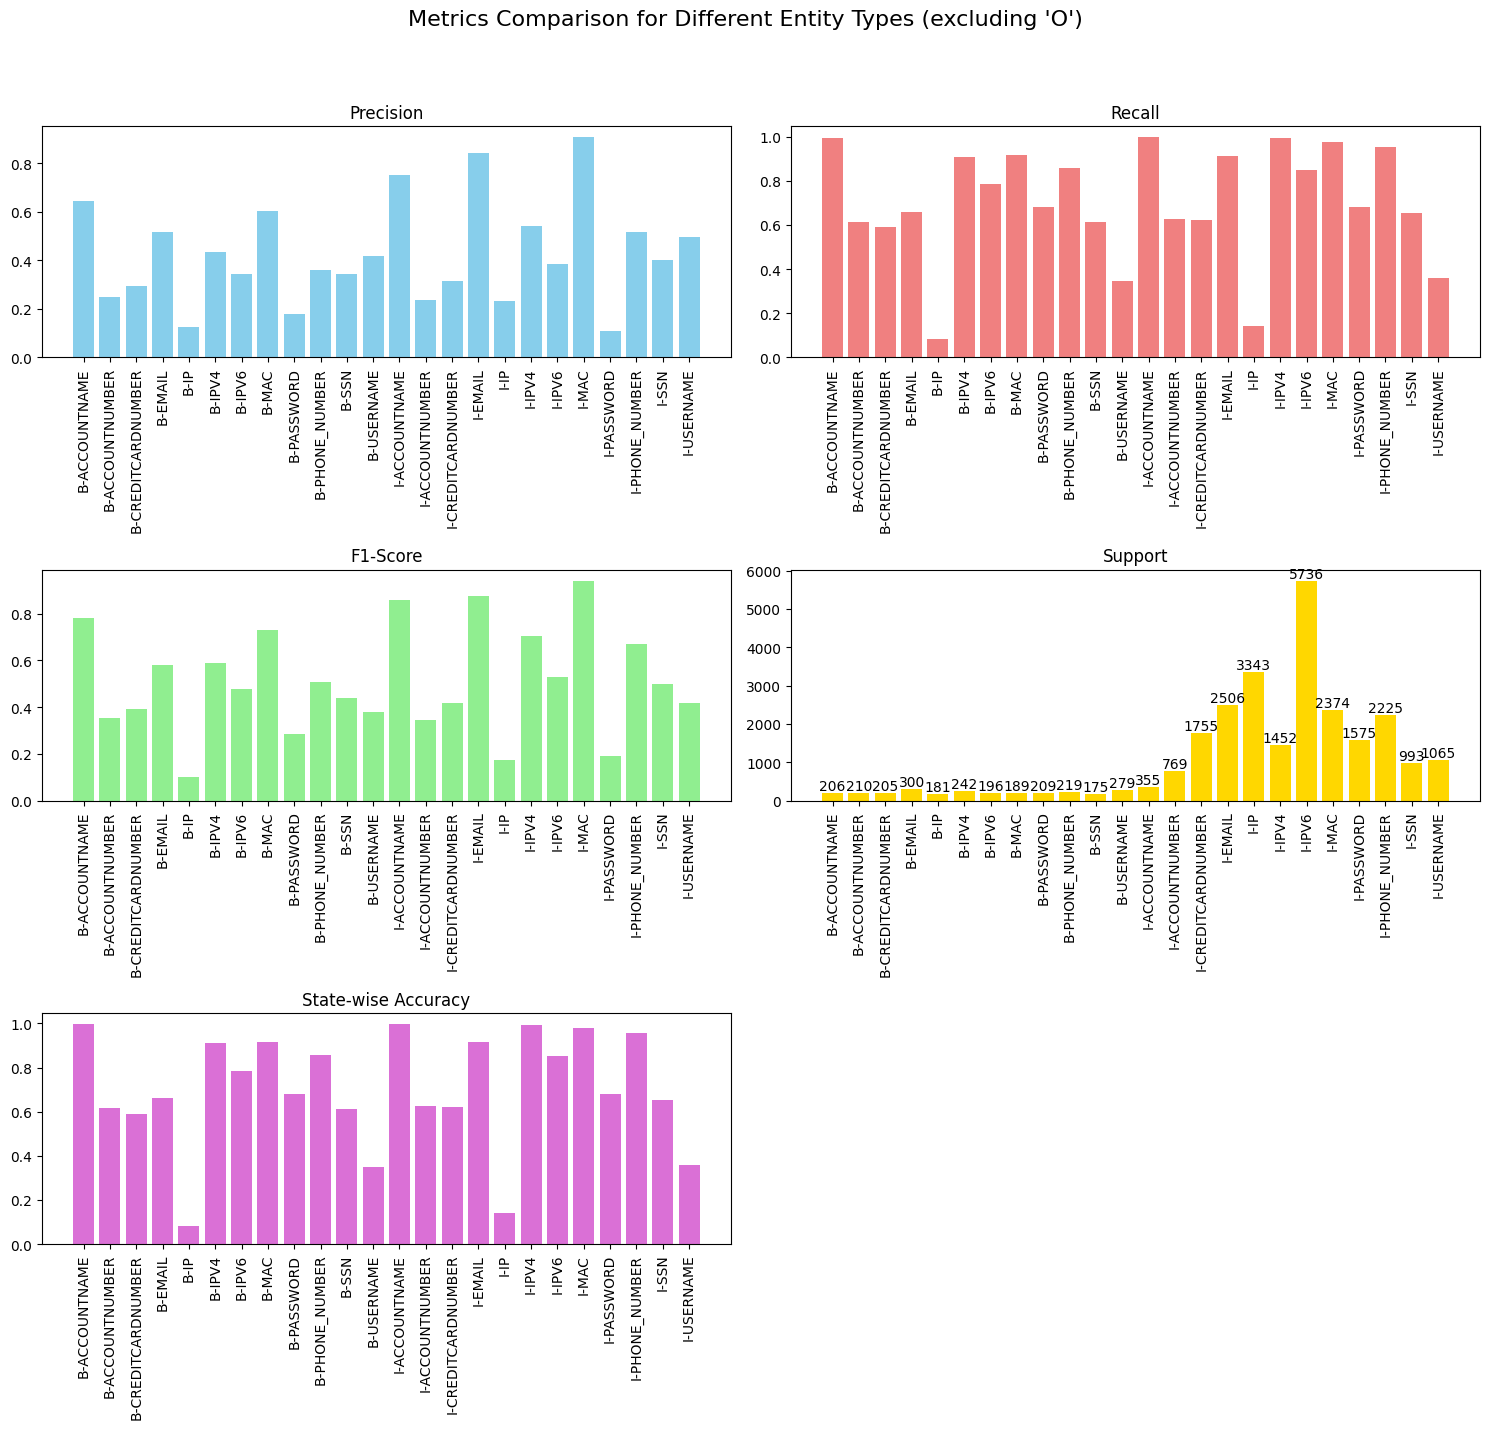


Confusion Matrix (excluding 'O'):


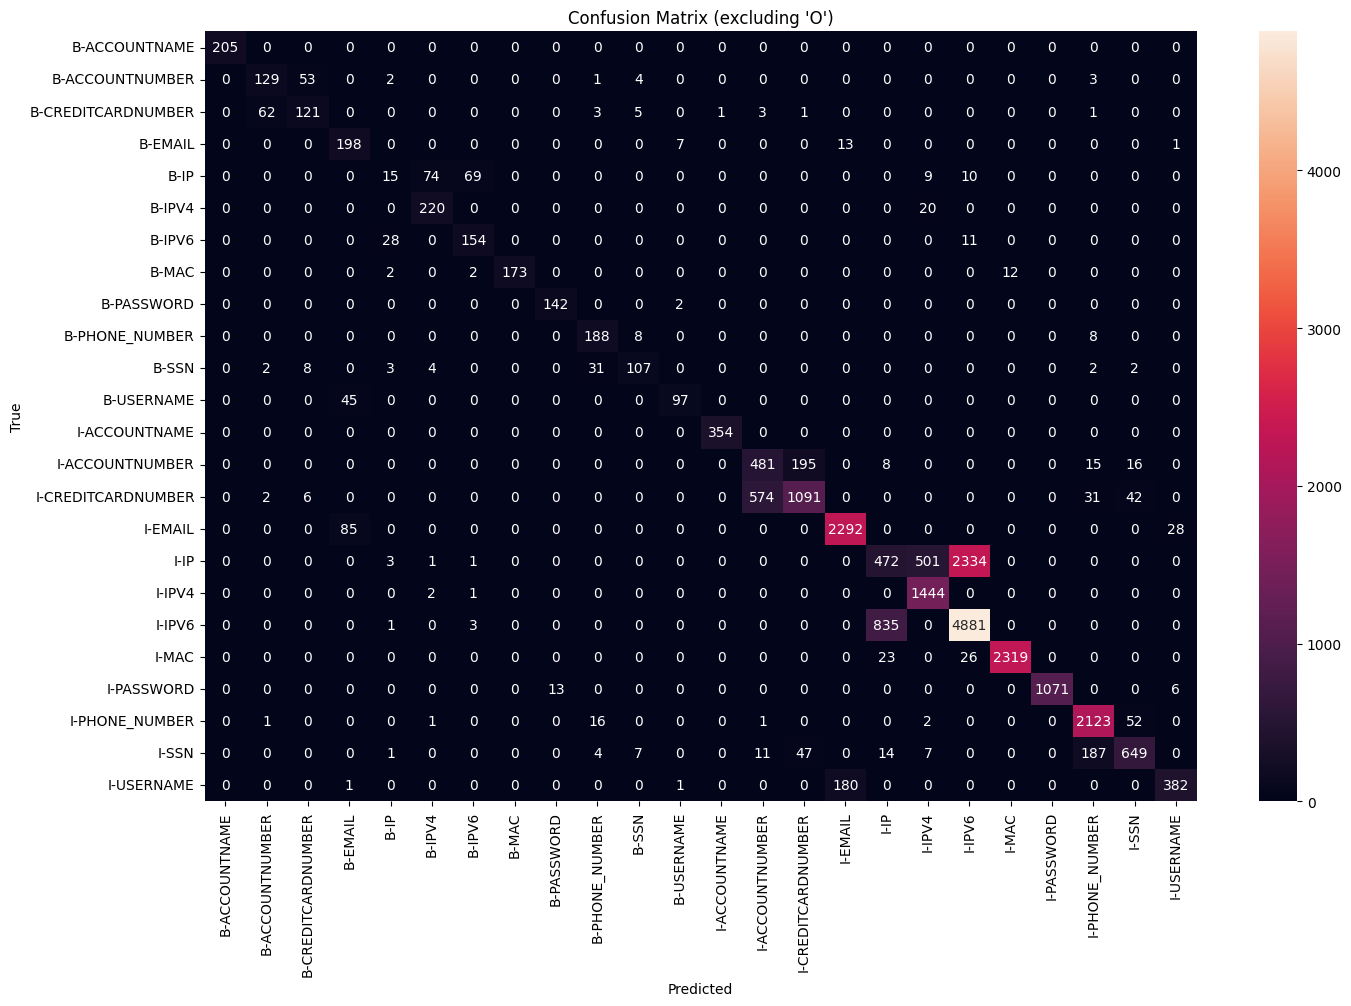

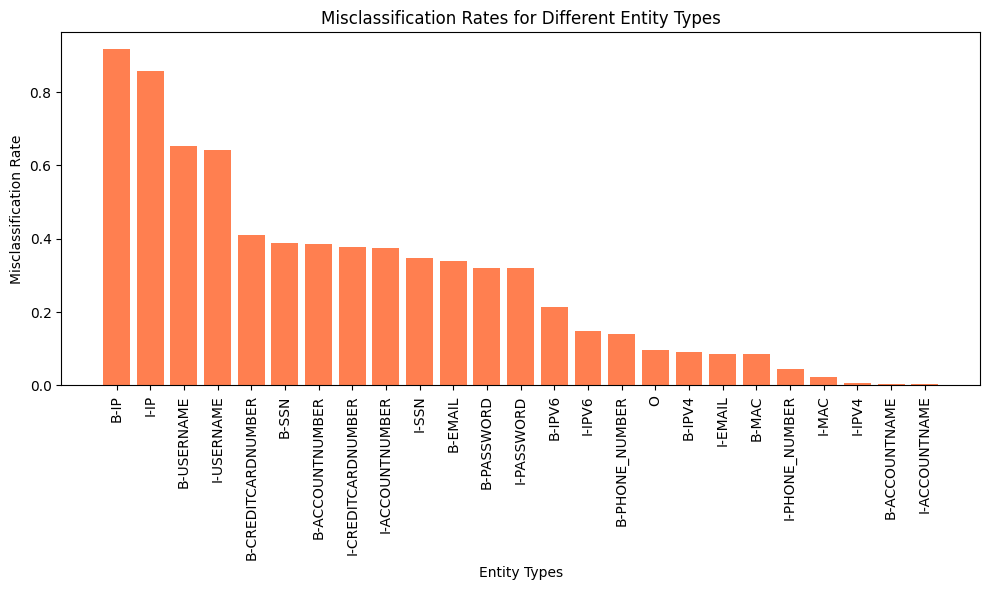

In [17]:
# Step 9: Evaluate model
evaluate_model(
    hmm_model,
    test_ner_tags,
    test_tokens,
    n_test,
    states,
    index_to_tag,
 )